In [230]:
import itertools 

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.lines as mlines
import matplotlib.path as mpath
import matplotlib.transforms as mtransforms
import matplotlib.markers as mmarkers
from matplotlib import patheffects

In [231]:
vals = np.linspace(-5, 5, 100)
x, y = np.meshgrid(vals, vals)
img = np.sin(x*y)

with plt.style.context('dark_background'):
    fig, ax = plt.subplots(1, 3, figsize=(3.5, 1.5), layout='constrained')
    fig.suptitle("Dark mode colormaps")
    for i, cmap in enumerate(['berlin', 'managua','vanimo']):
        im = ax[i].imshow(img, cmap=cmap)
        ax[i].set_title(cmap, fontsize=8)
        ax[i].set(xticks=[], yticks=[])
        cb = fig.colorbar(im, ax=ax[i], aspect=10, fraction=.1, pad=.05)
        cb.set_ticks([])
        
    
    #fig.savefig("darkcmap.png")
    fig.savefig("darkmap.pdf", dpi=300, bbox_inches='tight')

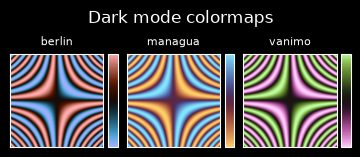

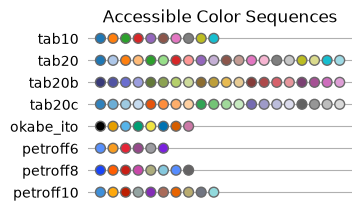

In [232]:
def plot_color_sequences(names, ax):
    # Display each named color sequence horizontally on the supplied axes.

    for n, name in enumerate(names):
        colors = mpl.color_sequences[name]
        n_colors = len(colors)
        x = np.arange(n_colors)
        y = np.full_like(x, n)

        ax.scatter(x, y, facecolor=colors, edgecolor='dimgray', s=50, zorder=2)

    ax.set_yticks(range(len(names)), labels=names)
    ax.grid(visible=True, axis='y')
    ax.yaxis.set_inverted(True)
    ax.xaxis.set_visible(False)
    ax.spines[:].set_visible(False)
    ax.tick_params(left=False)


built_in_color_sequences = [
    'tab10', 'tab20', 'tab20b', 'tab20c', 'okabe_ito', 'petroff6', 'petroff8',
    'petroff10', ]


fig, ax = plt.subplots(figsize=(3.5, 2), layout='compressed')

plot_color_sequences(built_in_color_sequences, ax)
ax.set_title('Accessible Color Sequences')
fig.savefig("color_sequences.pdf", dpi=300, bbox_inches='tight')
plt.show()


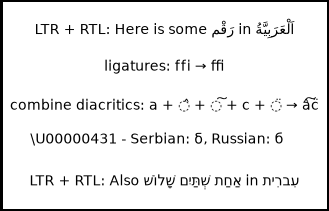

In [238]:
textd = (
    'a\N{Combining Circumflex Accent}\N{Combining Double Tilde}'
    'c\N{Combining Diaeresis}')
textd = ' + '.join(
    c if c in 'ac' else f'\N{Dotted Circle}{c}'
    for c in textd) + f' \N{Rightwards Arrow} {textd}'
texts = ['LTR + RTL: Here is some رَقْم in اَلْعَرَبِيَّةُ',
        'ligatures: f\N{Hair Space}f\N{Hair Space}i \N{Rightwards Arrow} ffi',
         f'combine diacritics: {textd}',
         "",
        'LTR + RTL: Also אַחַת שְׁתַּיִם שָׁלוֹשׁ in עִברִית']

fig, ax = plt.subplots(figsize=(3.5, 2), layout="compressed")
ax.set(xlim=(0,1), ylim=(0,1), aspect='equal')
inds = np.linspace(.1,.9, len(texts))[::-1]
for y, tx in zip(inds, texts):
    ax.text(0.5, y, tx, ha='center', va='center')

char = '\U00000431'
l = ax.text(-.2, inds[-2], f'\\U{ord(char):08x} - ', horizontalalignment='left')
s = ax.annotate(f'Serbian: {char}', xy=(1,0), xycoords=l, language='sr', va='bottom', ha='left')
ax.annotate(f', Russian: {char}', xy=(1,0), xycoords=s, language='ru', va='bottom', ha='left')
ax.axis('off')

fig.patch.set_edgecolor('k')
fig.patch.set_linewidth(2.5)
fig.savefig("libraqm.pdf", dpi=300, bbox_inches='tight')
plt.show()

<>:37: SyntaxWarning: invalid escape sequence '\o'
<>:37: SyntaxWarning: invalid escape sequence '\o'
<>:37: SyntaxWarning: invalid escape sequence '\o'
<>:37: SyntaxWarning: invalid escape sequence '\o'
C:\Users\story\AppData\Local\Temp\ipykernel_15628\3574219856.py:37: SyntaxWarning: invalid escape sequence '\o'
  r"$\mathcal{A}$","$\o$" , mmarkers.MarkerStyle("$\o$", 'left', mtransforms.Affine2D().rotate_deg(45)),
C:\Users\story\AppData\Local\Temp\ipykernel_15628\3574219856.py:37: SyntaxWarning: invalid escape sequence '\o'
  r"$\mathcal{A}$","$\o$" , mmarkers.MarkerStyle("$\o$", 'left', mtransforms.Affine2D().rotate_deg(45)),


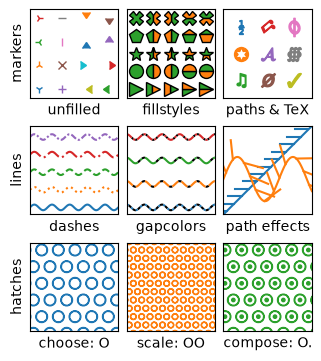

In [221]:
#multiple markers, multiple lines, and multiple hatches, possibly in three subplots side by side.
fig, axes = plt.subplots(3,3, figsize= (3.5,3.5), layout='compressed')

for ax in axes.flat:
    ax.set(xlim=(0,1), ylim=(0,1), aspect='equal', xticks=[], yticks=[]) 

# markers
mlist = [m for m, func in mlines.Line2D.markers.items()
                    if func != 'nothing' and m not in mlines.Line2D.filled_markers and m not in [',', 0,1,2,3]]
x = np.linspace(.1,.9, 4)
y = np.linspace(.1,.9, 4)
for (xi, yi), ms in zip(itertools.product(x,y), mlist):
    axes[0,0].plot(xi, yi, marker=ms)


filled_marker_style = dict(linestyle=':',  markersize=10,
                           color='darkgrey',
                           markerfacecolor='tab:green',
                           markerfacecoloralt='tab:orange',
                           markeredgecolor='k')

for yi, m in zip(np.linspace(.1,.9, 5), ['>', 'o', '*' , 'p', 'X']):
    for xi, fs in zip(np.linspace(.1,.9, 5), mlines.Line2D.fillStyles[:-1]):
        axes[0,1].plot(xi, yi, marker=m, fillstyle=fs, **filled_marker_style)



star = mpath.Path.unit_regular_star(6)
circle = mpath.Path.unit_circle()
# concatenate the circle with an internal cutout of the star
cut_star = mpath.Path(
    vertices=np.concatenate([circle.vertices, star.vertices[::-1, ...]]),
    codes=np.concatenate([circle.codes, star.codes]))

mlist = [r"$\frac{1}{2}$", cut_star, 
           "$\u266B$",  mmarkers.MarkerStyle("$\u266B$", 'left', mtransforms.Affine2D().rotate_deg(130)),
           r"$\mathcal{A}$","$\o$" , mmarkers.MarkerStyle("$\o$", 'left', mtransforms.Affine2D().rotate_deg(45)), 
         r"$\oiiint$", r"$\checkmark$"]

x = np.linspace(.2,.8, 3)
y = np.linspace(.2,.8, 3)[::-1]
for (xi, yi), ms in zip(itertools.product(x,y), mlist):
    axes[0,2].plot(xi, yi, marker=ms, markersize=10)

axes[0,0].set_ylabel("markers")
axes[0,0].set_xlabel("unfilled")
axes[0,1].set_xlabel("fillstyles")
axes[0,2].set_xlabel("paths & TeX")

#lines
axes[1,0].set_ylabel("lines")
axes[1,0].set_xlabel("dashes")
axes[1,1].set_xlabel("gapcolors")
axes[1,2].set_xlabel("path effects")


x = np.linspace(0, 2*np.pi, 1000)
y1 = np.sin(x*5)*.2
axes[1,0].set(xlim=(0, 2*np.pi), ylim=(0, 2*np.pi), aspect='equal')
linestyles = ['solid', 'dotted', 'dashed', 'dashdot',   (0, (3, 1, 1, 1))]
for offset, ls in zip(np.linspace(.5, 5.5, len(linestyles)), linestyles):
  axes[1,0].plot(x,y1 + offset, ls=ls)

x = np.linspace(0, 2*np.pi, 1000)
y1 = np.sin(x*5)*.2
y2 = np.cos(x*5)*.2
axes[1,1].set(xlim=(0, 2*np.pi), ylim=(0, 2*np.pi), aspect='equal')
linestyles = ['dotted', 'dashed', 'dashdot',   (0, (3, 1, 1, 1))]
for offset, ls in zip(np.linspace(.5, 5.5, len(linestyles)), linestyles):
  axes[1,1].plot(x,y2 + offset, ls=ls, gapcolor='black')

nx = 101
x = np.linspace(0.0, 1.0, nx)
y = 0.25*np.sin(x*10) + 0.4
axes[1,2].plot([0,1],[0,1],   path_effects=[patheffects.withTickedStroke(spacing=7, angle=135)])
axes[1,2].plot(x, y, path_effects=[patheffects.withTickedStroke()])

#hatches 
axes[2,0].set_xlabel("choose: O")
axes[2,0].set_ylabel("hatches")
axes[2,0].patch.set_hatch('O')
axes[2,0].patch.set_hatchcolor('tab:blue')
axes[2,1].set_xlabel("scale: OO")
axes[2,1].patch.set_hatch('OO')
axes[2,1].patch.set_hatchcolor('tab:orange')
axes[2,2].set_xlabel("compose: O.")
axes[2,2].patch.set_hatch('O.')
axes[2,2].patch.set_hatchcolor('tab:green')
fig.savefig("patterns.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [147]:
 len(mlist)

7

In [72]:
np.random.random?

Signature: np.random.random(size=None)
Docstring:
random(size=None)

Return random floats in the half-open interval [0.0, 1.0). Alias for
`random_sample` to ease forward-porting to the new random API.
Type:      method

In [93]:
mlines.Line2D.markers

{'.': 'point',
 ',': 'pixel',
 'o': 'circle',
 'v': 'triangle_down',
 '^': 'triangle_up',
 '<': 'triangle_left',
 '>': 'triangle_right',
 '1': 'tri_down',
 '2': 'tri_up',
 '3': 'tri_left',
 '4': 'tri_right',
 '8': 'octagon',
 's': 'square',
 'p': 'pentagon',
 '*': 'star',
 'h': 'hexagon1',
 'H': 'hexagon2',
 '+': 'plus',
 'x': 'x',
 'D': 'diamond',
 'd': 'thin_diamond',
 '|': 'vline',
 '_': 'hline',
 'P': 'plus_filled',
 'X': 'x_filled',
 0: 'tickleft',
 1: 'tickright',
 2: 'tickup',
 3: 'tickdown',
 4: 'caretleft',
 5: 'caretright',
 6: 'caretup',
 7: 'caretdown',
 8: 'caretleftbase',
 9: 'caretrightbase',
 10: 'caretupbase',
 11: 'caretdownbase',
 'None': 'nothing',
 'none': 'nothing',
 ' ': 'nothing',
 '': 'nothing'}